In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import soundfile as sf

In [3]:
"""
vibration.py
------------
Simulates on-body accelerometer-style vibration signals from clean audio.

Design rationale (from thesis proposal):
  Real accelerometers capture low-frequency mechanical coupling of vocalizations
  through the bird's body. We approximate this by:
    1. Extracting a temporal energy envelope (short-time RMS)
    2. Low-pass filtering to keep only sub-300 Hz mechanical frequencies
    3. Adding mild Gaussian noise + transient artifacts to mimic sensor imperfections

This signal is used in TWO ways:
  - Per-source vibrations v1, v2  → auxiliary weak-supervision loss ONLY (training)
  - Mixture vibration mix_vib     → model conditioning input (train + inference)
"""

import torch
import torch.nn.functional as F


def simulate_vibration(
    audio: torch.Tensor,
    sr: int = 22050,
    frame_size: int = 512,
    hop_size: int = 128,
    lp_cutoff_hz: float = 300.0,
    noise_std: float = 0.005,
    transient_prob: float = 0.02,
) -> torch.Tensor:
    """
    Simulate a vibration signal from an audio waveform.

    Args:
        audio       : Tensor of shape [T] or [B, T] or [B, 1, T]
        sr          : Sample rate in Hz (default 22050)
        frame_size  : STFT-style frame for RMS envelope
        hop_size    : Hop between frames
        lp_cutoff_hz: Low-pass cutoff (mechanical frequency ceiling)
        noise_std   : Gaussian sensor noise standard deviation
        transient_prob: Per-sample probability of adding a transient spike

    Returns:
        vibration   : Tensor of the same shape as `audio`
    """
    # ── normalise shape to [B, T] ──────────────────────────────────────────
    original_shape = audio.shape
    squeeze_batch = False
    if audio.dim() == 1:
        audio = audio.unsqueeze(0)          # [1, T]
        squeeze_batch = True
    elif audio.dim() == 3:
        audio = audio.squeeze(1)            # [B, 1, T] → [B, T]

    B, T = audio.shape

    # ── 1. Short-time RMS envelope ─────────────────────────────────────────
    # Unfold into overlapping frames: [B, num_frames, frame_size]
    audio_padded = F.pad(audio, (frame_size // 2, frame_size // 2))
    frames = audio_padded.unfold(-1, frame_size, hop_size)          # [B, F, frame_size]
    rms = frames.pow(2).mean(dim=-1).sqrt()                         # [B, F]

    # Upsample RMS back to original length
    rms = rms.unsqueeze(1)                                          # [B, 1, F]
    vib = F.interpolate(rms, size=T, mode='linear', align_corners=False)  # [B, 1, T]
    vib = vib.squeeze(1)                                            # [B, T]

    # ── 2. Low-pass filter (approximate with large average pool) ──────────
    # Cutoff ≈ sr / (2 * kernel_half_size); kernel chosen to match lp_cutoff_hz
    kernel_size = max(3, int(sr / (2 * lp_cutoff_hz)))
    if kernel_size % 2 == 0:
        kernel_size += 1
    vib = vib.unsqueeze(1)                                          # [B, 1, T]
    vib = F.avg_pool1d(vib, kernel_size=kernel_size,
                       stride=1, padding=kernel_size // 2)
    vib = vib.squeeze(1)                                            # [B, T]

    # ── 3. Sensor noise ───────────────────────────────────────────────────
    noise = torch.randn_like(vib) * noise_std
    vib = vib + noise

    # ── 4. Sparse transient artifacts ────────────────────────────────────
    mask = torch.bernoulli(torch.full_like(vib, transient_prob))
    spikes = torch.randn_like(vib) * 0.1 * mask
    vib = vib + spikes

    # ── 5. Normalise to [-1, 1] per sample ───────────────────────────────
    peak = vib.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
    vib = vib / peak

    # ── restore original shape ────────────────────────────────────────────
    if squeeze_batch:
        vib = vib.squeeze(0)
    elif len(original_shape) == 3:
        vib = vib.unsqueeze(1)

    return vib


In [4]:
audio, sr = torchaudio.load("dataset/wavfiles/11713-1.wav")
print(audio.shape, sr)

torch.Size([1, 66150]) 22050


In [7]:
sr = 22050
frame_size = 512
hop_size = 128
lp_cutoff_hz = 300.0
noise_std = 0.0051
transient_prob = 0.02

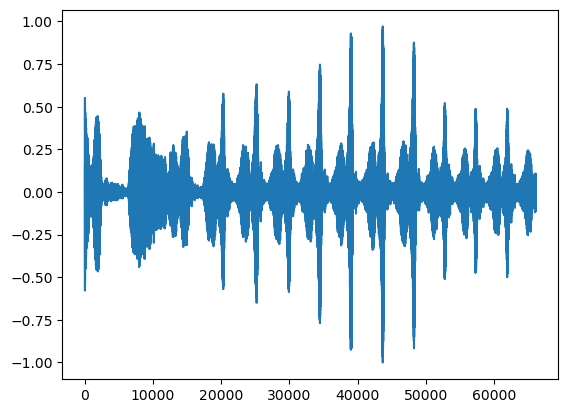

In [8]:
plt.plot(audio[0])
plt.show()

In [9]:
original_shape = audio.shape
squeeze_batch = False
if audio.dim() == 1:
    audio = audio.unsqueeze(0)          # [1, T]
    squeeze_batch = True
elif audio.dim() == 3:
    audio = audio.squeeze(1)            # [B, 1, T] → [B, T]

B, T = audio.shape

# ── 1. Short-time RMS envelope ─────────────────────────────────────────
# Unfold into overlapping frames: [B, num_frames, frame_size]
audio_padded = F.pad(audio, (frame_size // 2, frame_size // 2))
frames = audio_padded.unfold(-1, frame_size, hop_size)          # [B, F, frame_size]
rms = frames.pow(2).mean(dim=-1).sqrt()                         # [B, F]

print(rms.shape)


torch.Size([1, 517])


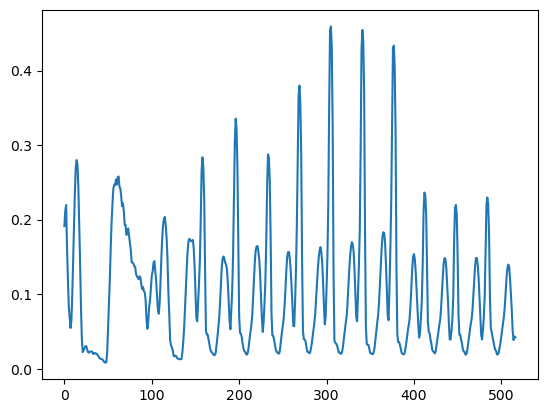

In [10]:
plt.plot(rms[0].numpy())

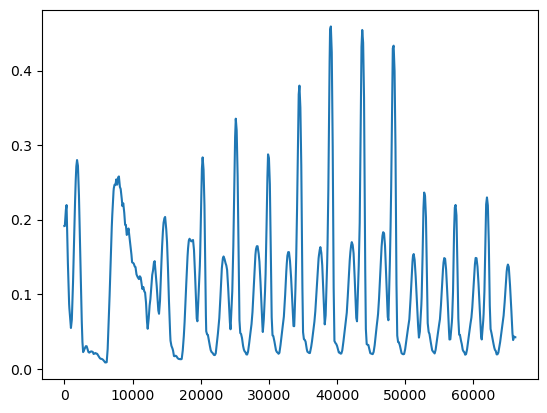

In [11]:
rms = rms.unsqueeze(1)                                          # [B, 1, F]
vib = F.interpolate(rms, size=T, mode='linear', align_corners=False)  # [B, 1, T]
vib = vib.squeeze(1) 

plt.plot(vib[0])
plt.show()

 ...]

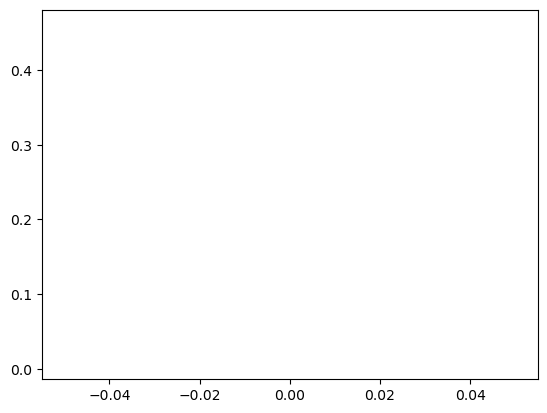

In [12]:
kernel_size = max(3, int(sr / (2 * lp_cutoff_hz)))
if kernel_size % 2 == 0:
    kernel_size += 1
vib = vib.unsqueeze(1)                                          # [B, 1, T]
vib = F.avg_pool1d(vib, kernel_size=kernel_size,
                    stride=1, padding=kernel_size // 2)
vib = vib.squeeze(1)   


plt.plot(vib)

 ...]

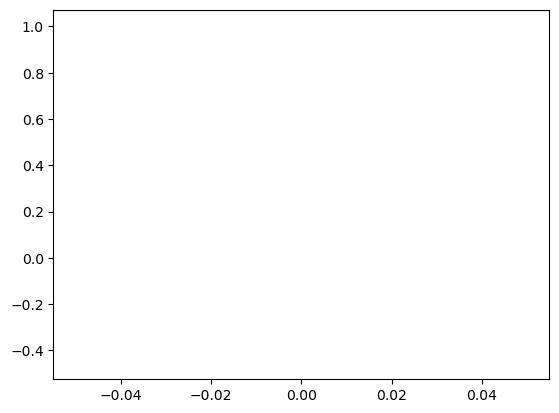

In [14]:
# ── 4. Sparse transient artifacts ────────────────────────────────────
mask = torch.bernoulli(torch.full_like(vib, transient_prob))
spikes = torch.randn_like(vib) * 0.1 * mask
vib = vib + spikes

# ── 5. Normalise to [-1, 1] per sample ───────────────────────────────
peak = vib.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
vib = vib / peak

plt.plot(vib)

Visualization successfully saved to vibration_simulation_stages.png


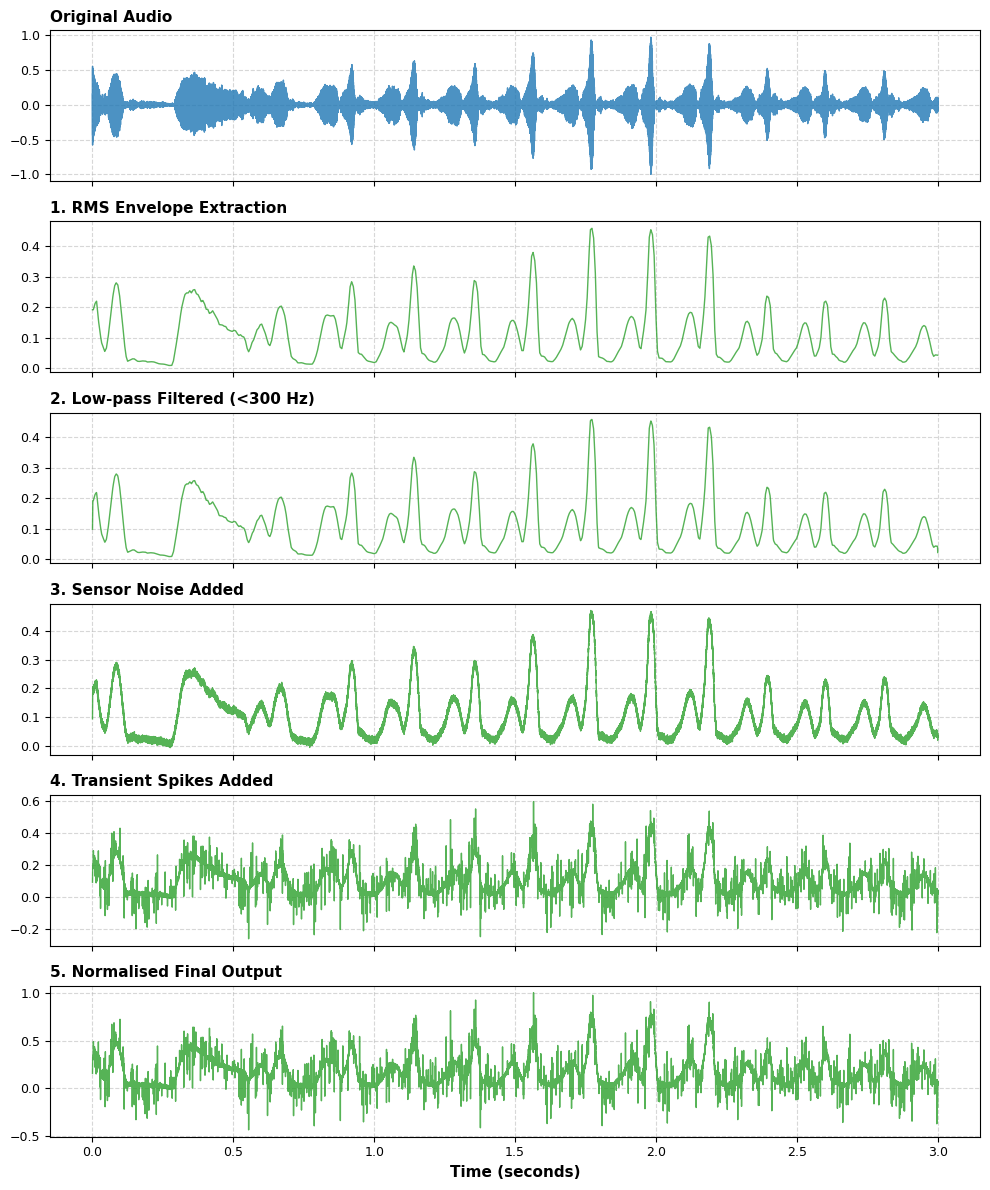

In [15]:
import torch
import torch.nn.functional as F
import torchaudio
import matplotlib.pyplot as plt

def simulate_vibration_with_stages(
    audio: torch.Tensor,
    sr: int = 22050,
    frame_size: int = 512,
    hop_size: int = 128,
    lp_cutoff_hz: float = 300.0,
    noise_std: float = 0.005,
    transient_prob: float = 0.02,
):
    """
    Simulates vibration while keeping track of intermediate stages for plotting.
    """
    stages = {}
    
    # ── Normalise shape to [B, T] ──────────────────────────────────────────
    original_shape = audio.shape
    squeeze_batch = False
    if audio.dim() == 1:
        audio = audio.unsqueeze(0)          # [1, T]
        squeeze_batch = True
    elif audio.dim() == 3:
        audio = audio.squeeze(1)            # [B, 1, T] → [B, T]

    B, T = audio.shape
    
    # Store Stage 0: Original Audio
    stages['Original Audio'] = audio.clone()

    # ── 1. Short-time RMS envelope ─────────────────────────────────────────
    audio_padded = F.pad(audio, (frame_size // 2, frame_size // 2))
    frames = audio_padded.unfold(-1, frame_size, hop_size)          # [B, F, frame_size]
    rms = frames.pow(2).mean(dim=-1).sqrt()                         # [B, F]

    # Upsample RMS back to original length
    rms = rms.unsqueeze(1)                                          # [B, 1, F]
    vib = F.interpolate(rms, size=T, mode='linear', align_corners=False)  # [B, 1, T]
    vib = vib.squeeze(1)                                            # [B, T]
    stages['1. RMS Envelope Extraction'] = vib.clone()

    # ── 2. Low-pass filter (approximate with large average pool) ──────────
    kernel_size = max(3, int(sr / (2 * lp_cutoff_hz)))
    if kernel_size % 2 == 0:
        kernel_size += 1
    vib = vib.unsqueeze(1)                                          # [B, 1, T]
    vib = F.avg_pool1d(vib, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    vib = vib.squeeze(1)                                            # [B, T]
    stages['2. Low-pass Filtered (<300 Hz)'] = vib.clone()

    # ── 3. Sensor noise ───────────────────────────────────────────────────
    noise = torch.randn_like(vib) * noise_std
    vib = vib + noise
    stages['3. Sensor Noise Added'] = vib.clone()

    # ── 4. Sparse transient artifacts ────────────────────────────────────
    mask = torch.bernoulli(torch.full_like(vib, transient_prob))
    spikes = torch.randn_like(vib) * 0.1 * mask
    vib = vib + spikes
    stages['4. Transient Spikes Added'] = vib.clone()

    # ── 5. Normalise to [-1, 1] per sample ───────────────────────────────
    peak = vib.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
    vib = vib / peak
    stages['5. Normalised Final Output'] = vib.clone()

    # Extract the first channel/batch element for 1D visualization
    for key in stages:
        stages[key] = stages[key][0].detach().cpu().numpy()
        
    return stages

# ── Main Execution ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    # 1. Load the audio file
    # Note: If your audio sample rate differs from 22050, the code adapts automatically via `sr`
    audio, sr = torchaudio.load("dataset/wavfiles/11713-1.wav")
    
    # 2. Extract intermediate signals from simulation
    stages = simulate_vibration_with_stages(audio, sr=sr)
    
    # 3. Create a timeline in seconds
    duration = audio.shape[-1] / sr
    import numpy as np
    time_axis = np.linspace(0, duration, audio.shape[-1])
    
    # 4. Set up the multi-panel plot
    fig, axes = plt.subplots(6, 1, figsize=(10, 12), sharex=True)
    
    # List stages sequentially
    stage_keys = [
        'Original Audio', 
        '1. RMS Envelope Extraction', 
        '2. Low-pass Filtered (<300 Hz)', 
        '3. Sensor Noise Added', 
        '4. Transient Spikes Added', 
        '5. Normalised Final Output'
    ]
    
    # Plot each stage
    for i, key in enumerate(stage_keys):
        # Use a distinct color for the raw acoustic signal vs. physical vibration signals
        color = '#1f77b4' if i == 0 else '#2ca02c'
        axes[i].plot(time_axis, stages[key], color=color, alpha=0.8, linewidth=1)
        axes[i].set_title(key, fontsize=11, fontweight='bold', loc='left')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].tick_params(axis='both', which='major', labelsize=9)
        
    # X-axis configuration
    axes[-1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    
    # Custom layout adjustments to guarantee no overlapping or truncation
    plt.tight_layout()
    
    # Save the figure
    output_filename = "vibration_simulation_stages.png"
    plt.savefig(output_filename, dpi=150)
    print(f"Visualization successfully saved to {output_filename}")